In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.isnull().mean()

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns=["RowNumber", "CustomerId" , "Surname"] , inplace=True)
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

In [8]:
#Encoding 
df = pd.get_dummies(df, columns=["Geography" , "Gender"], drop_first=True , dtype='int')

In [9]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [10]:
X=df.drop(columns=["Exited"]) 
y=df["Exited"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [12]:
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

tf.random.set_seed(42)

In [13]:
from tensorflow.keras.layers import Dense 
model=Sequential([
    Dense(units=4 , activation='relu' , input_shape=(X.shape[1],)),
    Dense(units=2 , activation='relu' ),
    Dense(units=1, activation='sigmoid')
]) 

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              10 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history=model.fit(X_train,y_train,batch_size=5,epochs=30,verbose=1,validation_split=0.2)

Epoch 1/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5717 - loss: 7718.4575 - val_accuracy: 0.6681 - val_loss: 194.1695
Epoch 2/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6714 - loss: 25.1677 - val_accuracy: 0.7606 - val_loss: 1.6430
Epoch 3/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6755 - loss: 11.4601 - val_accuracy: 0.7987 - val_loss: 11.6547
Epoch 4/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6745 - loss: 11.7907 - val_accuracy: 0.7987 - val_loss: 12.7816
Epoch 5/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6697 - loss: 10.3149 - val_accuracy: 0.7987 - val_loss: 2.6664
Epoch 6/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6787 - loss: 8.6822 - val_accuracy: 0.7987 - val_loss: 7.0415
Epoch 7/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6753 - loss: 5.5107 - val_accuracy: 0.7987 - val_loss: 1.6949
Epoch 8/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6928 - loss

In [17]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [18]:
y_pred

array([[0.2067791],
       [0.2067791],
       [0.2067791],
       ...,
       [0.2067791],
       [0.2067791],
       [0.2067791]], shape=(2000, 1), dtype=float32)

In [19]:
y_pred = y_pred.argmax(axis=-1)

In [20]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8035

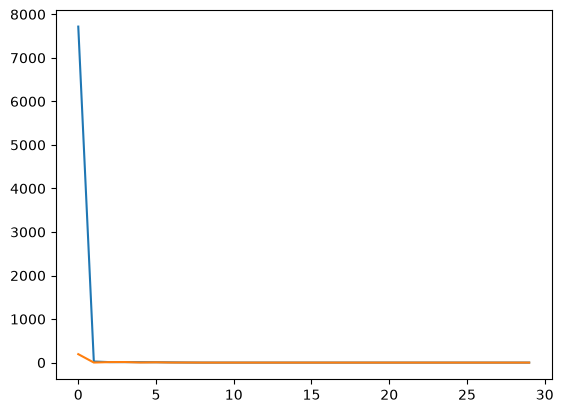

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

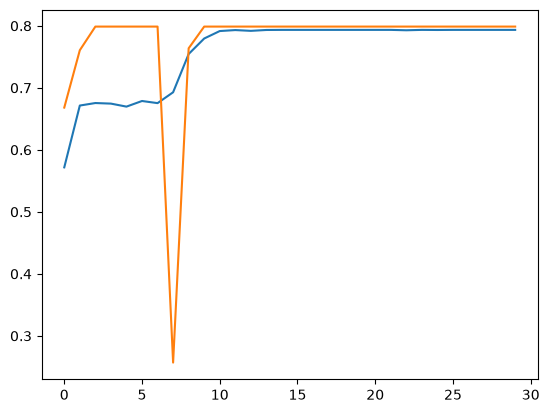

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

### With Scaling

In [24]:
history=model.fit(X_train_scaled,y_train,batch_size=5,epochs=30,verbose=1,validation_split=0.2)

Epoch 1/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7967 - loss: 0.4617 - val_accuracy: 0.8163 - val_loss: 0.4317
Epoch 2/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8100 - loss: 0.4352 - val_accuracy: 0.8181 - val_loss: 0.4263
Epoch 3/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8119 - loss: 0.4298 - val_accuracy: 0.8225 - val_loss: 0.4252
Epoch 4/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8134 - loss: 0.4266 - val_accuracy: 0.8231 - val_loss: 0.4242
Epoch 5/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8142 - loss: 0.4240 - val_accuracy: 0.8200 - val_loss: 0.4235
Epoch 6/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8153 - loss: 0.4218 - val_accuracy: 0.8200 - val_loss: 0.4220
Epoch 7/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8161 - loss: 0.4194 - val_accuracy: 0.8213 - val_loss: 0.4199
Epoch 8/30
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8164 - loss: 0.4168 - 

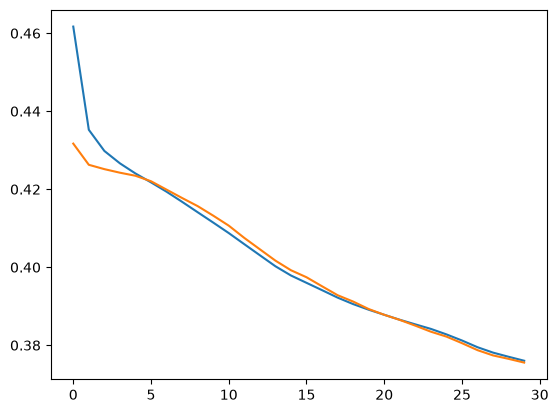

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

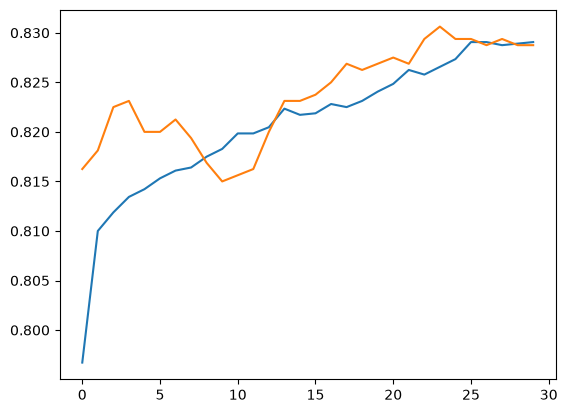

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])